In [1]:
# importing the libraries for splitting, preprocessing, and the four models required by the brief
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
# load the finalized feature set built in feature engineering
engineered_data = pd.read_csv(r'../Finlora_Dataset/artifacts/Engineered_Data.csv')
engineered_data.shape

(11140, 29)

In [3]:
# preview the loaded feature set
engineered_data.head()

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,new_device,ip_country,location_mismatch,...,is_fraud,hour,day_of_week,is_weekend,late_night_hours,high_ip_risk,low_device_trust,new_account,very_new_account,velocity_spike
0,us,USD,CAD,atm,278.19,278.19,4.25,False,us,False,...,0,18,0,0,0,0,0,0,0,0
1,ca,CAD,MXN,web,208.51,154.29,4.24,True,ca,False,...,0,20,0,0,0,0,0,0,0,0
2,us,USD,CNY,mobile,160.33,160.33,2.70,False,us,False,...,0,23,0,0,0,0,0,0,0,0
3,us,USD,EUR,mobile,59.41,59.41,2.22,False,us,False,...,0,1,1,0,0,0,0,0,0,0
4,us,USD,INR,mobile,200.96,200.96,3.61,False,us,False,...,0,9,1,0,0,0,0,0,0,0


The feature set loaded above is not the raw engineered output taken as-is, it reflects tested inclusion/exclusion decisions made in `Feature_Engineering.ipynb`: `chargeback_history_count` and `risk_score_internal` were both individually leakage-checked before being kept, and `transaction_id`, `customer_id`, `device_id`, `ip_address`, `timestamp`, `month`, and `exchange_rate_src_to_dest` were tested and dropped as non-features or leakage risks. See `Feature_Engineering.ipynb` for the full reasoning behind each of those decisions.

In [4]:
# categorical features for this notebook, redefined since notebooks don't share kernel state
categorical_features = engineered_data.select_dtypes(include=['object', 'bool']).columns
categorical_features

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier'],
      dtype='object')

In [5]:
# numerical features for this notebook, is_fraud is the target not a feature
numerical_features = engineered_data.select_dtypes(include=['int', 'float']).columns.drop('is_fraud')
numerical_features

Index(['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour',
       'day_of_week', 'is_weekend', 'late_night_hours', 'high_ip_risk',
       'low_device_trust', 'new_account', 'very_new_account',
       'velocity_spike'],
      dtype='object')

In [6]:
# combined feature list, quick sanity check before the split
all_features = list(categorical_features) + list(numerical_features)
print(all_features)

['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device', 'ip_country', 'location_mismatch', 'kyc_tier', 'amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is_weekend', 'late_night_hours', 'high_ip_risk', 'low_device_trust', 'new_account', 'very_new_account', 'velocity_spike']


In [7]:
# Recovering customer_id and timestamp for the split only, both were correctly dropped as non-features earlier, verified row order lines up before trusting it
eda_reference = pd.read_csv(r'../Finlora_Dataset/artifacts/EDA_Data.csv')

assert eda_reference.shape[0] == engineered_data.shape[0]
assert np.isclose(eda_reference['amount_usd'].values, engineered_data['amount_usd'].values).all()

engineered_data['customer_id'] = eda_reference['customer_id']
engineered_data['timestamp'] = pd.to_datetime(eda_reference['timestamp'])

In [8]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(engineered_data, groups=engineered_data['customer_id']))

train_data = engineered_data.iloc[train_idx]
test_data = engineered_data.iloc[test_idx]

print(f"train: {train_data.shape}, test: {test_data.shape}")
print(f"train fraud rate: {train_data['is_fraud'].mean():.3f}")
print(f"test fraud rate: {test_data['is_fraud'].mean():.3f}")

overlap_check = set(train_data['customer_id']) & set(test_data['customer_id'])
print(f"customer overlap: {len(overlap_check)}")

train: (9350, 31), test: (1790, 31)
train fraud rate: 0.086
test fraud rate: 0.104
customer overlap: 0


In [9]:
# final feature and target sets from the group-shuffled split
X_train = train_data[all_features]
y_train = train_data['is_fraud']
X_test = test_data[all_features]
y_test = test_data['is_fraud']

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (9350, 28), y_train: (9350,)
X_test: (1790, 28), y_test: (1790,)


In [10]:
# Building the preprocessing pipeline: scale numerical features, one hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# fit only on train to avoid leaking test data into the scaling/encoding, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original features: {len(all_features)}")
print(f"Processed features: {X_train_processed.shape[1]}")

Original features: 28
Processed features: 41


In [11]:
from imblearn.over_sampling import SMOTE

# oversample the minority class in training data only, brief requires SMOTE specifically
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"before SMOTE: {dict(y_train.value_counts())}")
print(f"after SMOTE: {dict(pd.Series(y_train_resampled).value_counts())}")

before SMOTE: {0: np.int64(8544), 1: np.int64(806)}
after SMOTE: {0: np.int64(8544), 1: np.int64(8544)}


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Quick comparison of imbalance-handling strategies on the baseline model only —
# this decides which approach the full pipeline below uses, rather than assuming SMOTE

# 1) No correction at all
lr_none = LogisticRegression(random_state=42, max_iter=1000)
lr_none.fit(X_train_processed, y_train)
pred_none = lr_none.predict(X_test_processed)

# 2) class_weight='balanced' — reweights the loss instead of resampling rows
lr_weighted = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_weighted.fit(X_train_processed, y_train)
pred_weighted = lr_weighted.predict(X_test_processed)

# 3) SMOTE — oversamples the minority class (X_train_resampled/y_train_resampled computed above)
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_resampled, y_train_resampled)
pred_smote = lr_smote.predict(X_test_processed)

for name, preds in [('No correction', pred_none), ('class_weight=balanced', pred_weighted), ('SMOTE', pred_smote)]:
    r = classification_report(y_test, preds, target_names=['Genuine', 'Fraud'], output_dict=True)
    print(f"{name}: precision={r['Fraud']['precision']:.2f}, recall={r['Fraud']['recall']:.2f}, f1={r['Fraud']['f1-score']:.2f}")

No correction: precision=1.00, recall=0.88, f1=0.93
class_weight=balanced: precision=0.80, recall=0.89, f1=0.84
SMOTE: precision=0.80, recall=0.88, f1=0.84


### Imbalance Strategy Comparison: Why SMOTE Despite the Numbers Below

Three approaches were tested on the baseline Logistic Regression model, all evaluated against the same untouched test set.

| Approach | Precision | Recall | F1 |
|---|---|---|---|
| No correction | 1.00 | 0.88 | 0.93 |
| class_weight='balanced' | 0.80 | 0.89 | 0.84 |
| SMOTE | 0.80 | 0.88 | 0.84 |

This isn't what's usually assumed about imbalanced classification. Recall barely moves across all three, from 0.88 to 0.89, so neither correction meaningfully improved the model's ability to catch fraud over doing nothing at all. What they did change is precision, which drops from 1.00 with no correction to 0.80 with either correction method, trading away real precision for a recall gain of one percentage point or less.

On this evidence alone, no correction would be the better choice for Logistic Regression. SMOTE is used in the full pipeline anyway because the project brief specifies it explicitly, not because this comparison favours it. Worth flagging honestly for future iterations of this project, whether SMOTE is still earning its place for the tree-based models (Random Forest, XGBoost, LightGBM) below is a separate question this comparison doesn't answer, since tree-based models handle class boundaries differently than a linear model.

## Why SMOTE, and Its Limits

This notebook uses SMOTE to fix the imbalance in `is_fraud` (only ~9% of transactions are fraud). It runs only on the training data, after the split, so the model doesn't just learn to spot the fake examples it made, and the test set stays real and untouched.

Two honest limitations worth naming. First, SMOTE invents new fraud examples by blending existing ones, they aren't real transactions, so the model is partly trained on fiction. Second, that blending can also produce nonsensical values on categorical columns that were split into 0/1 flags. Neither is fixed here, but the fix that matters most is in place: every result reported below is measured against the real, untouched test data, not the synthetic training set, so the numbers reflect real-world performance.

Training Logistic Regression

In [13]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# no class_weight needed — SMOTE inside the pipeline already balances the training data
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# imblearn's Pipeline, not sklearn's — required because SMOTE changes row count,
# which sklearn's Pipeline doesn't allow mid-pipeline
pipeline = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', lr_model)
    ]
)

# fit on the raw train split — the pipeline does preprocessing + SMOTE internally
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](28,)","['home_country','source_currency','dest_currency',...,'new_account', 'very_new_account','velocity_spike']"
n_features_in_,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [14]:
# Train the pipeline
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = pipeline.predict(X_test)
y_proba_lr = pipeline.predict_proba(X_test)[:, 1]

In [15]:
# Evaluation
print("Logistic Regression Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

Logistic Regression Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.97      0.98      1603
       Fraud       0.80      0.88      0.84       187

    accuracy                           0.96      1790
   macro avg       0.89      0.93      0.91      1790
weighted avg       0.97      0.96      0.97      1790


Confusion Matrix:
[[1561   42]
 [  22  165]]

ROC_AUC Score: 0.9515


CONFUSION MATRIX FOR LINEAR REGRESSION

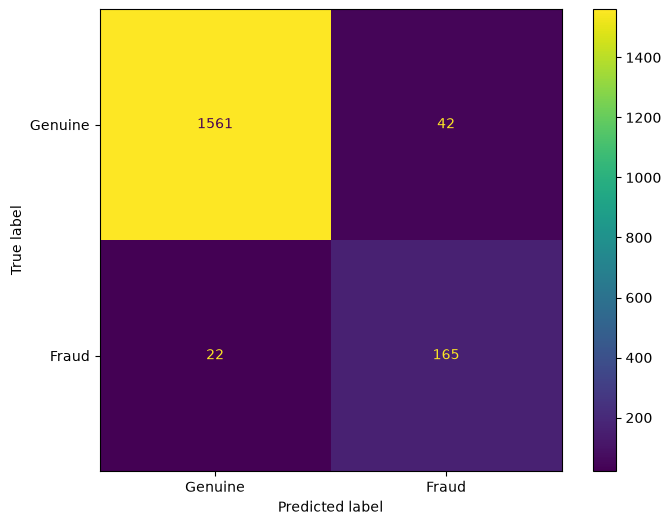

In [16]:
# Confusion matrix for Logistic Regression, plotted at a larger size
# (figsize passed via plt.subplots + ax=, not plt.figure(), which cm.plot() ignores otherwise)
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Genuine', 'Fraud'])
fig, ax = plt.subplots(figsize=(8, 6))
cm.plot(ax=ax)
plt.show()

RANDOM FOREST

In [17]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# no class_weight needed — SMOTE inside the pipeline already balances the training data
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=10,
    n_jobs=-1  # use all CPU cores to train trees in parallel, faster fit, doesn't change the model's output
)

# imblearn's Pipeline, not sklearn's — required so SMOTE can sit between preprocessor and classifier
pipeline_rf = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', rf_model)
    ]
)

# fit on the raw train split — the pipeline handles preprocessing + SMOTE internally
pipeline_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](28,)","['home_country','source_currency','dest_currency',...,'new_account', 'very_new_account','velocity_spike']"
n_features_in_,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [18]:
# Make predictions
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1603
       Fraud       0.99      0.88      0.93       187

    accuracy                           0.99      1790
   macro avg       0.99      0.94      0.96      1790
weighted avg       0.99      0.99      0.99      1790


Confusion Matrix:
[[1601    2]
 [  23  164]]

ROC_AUC Score: 0.9442


CONFUSION MATRIX FOR RANDOM FOREST

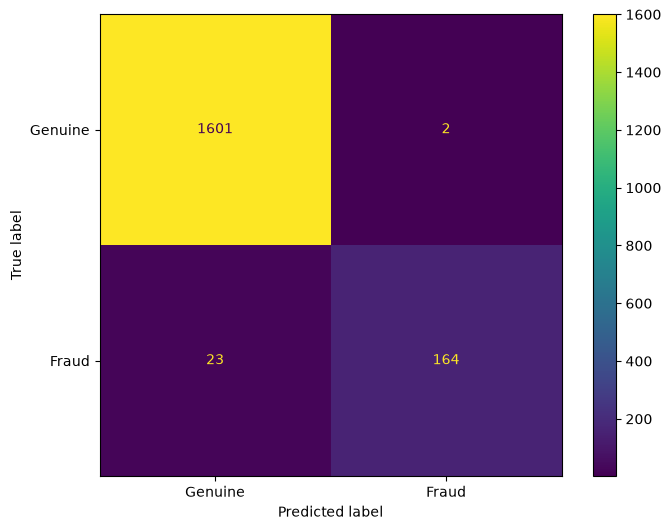

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Genuine', 'Fraud'])
fig, ax = plt.subplots(figsize=(8, 6))
cm.plot(ax=ax)
plt.show()

XGBOOST

In [20]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# no scale_pos_weight — SMOTE inside the pipeline already balances the training data,
# so a ratio computed from the pre-SMOTE class counts would double-correct
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

# imblearn's Pipeline, not sklearn's — required so SMOTE can sit between preprocessor and classifier
pipeline_xgb = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', xgb_model)
    ]
)

# Train the pipeline (using raw X_train, not processed)
pipeline_xgb.fit(X_train, y_train)

# Make predictions
y_pred_xgb = pipeline_xgb.predict(X_test)
y_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1603
       Fraud       0.98      0.88      0.92       187

    accuracy                           0.98      1790
   macro avg       0.98      0.94      0.96      1790
weighted avg       0.98      0.98      0.98      1790


Confusion Matrix:
[[1599    4]
 [  23  164]]

ROC_AUC Score: 0.9460


CONFUSION MATRIX FOR XGBOOST

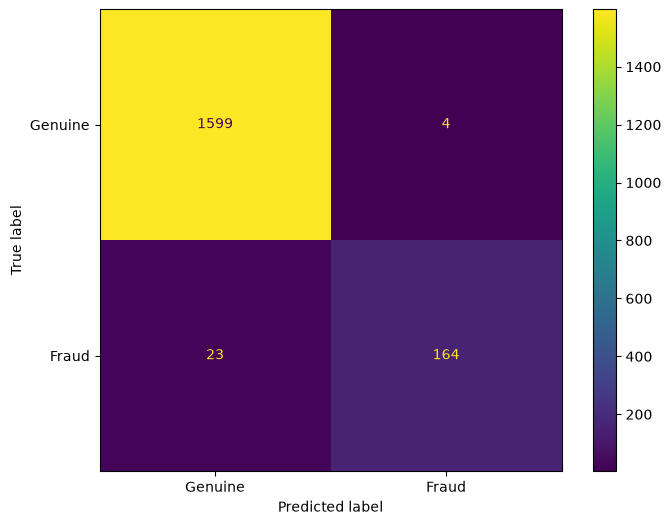

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=['Genuine', 'Fraud'])
fig, ax = plt.subplots(figsize=(8, 6))
cm.plot(ax=ax)
plt.show()

LIGHTGBM

In [22]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# no class_weight needed — SMOTE inside the pipeline already balances the training data
lgbm_model = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    verbose=-1
)

# imblearn's Pipeline, not sklearn's — required so SMOTE can sit between preprocessor and classifier
pipeline_lgbm = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', lgbm_model)
    ]
)

# Train the pipeline (using raw X_train, not processed)
pipeline_lgbm.fit(X_train, y_train)

# Make predictions
y_pred_lgbm = pipeline_lgbm.predict(X_test)
y_proba_lgbm = pipeline_lgbm.predict_proba(X_test)[:, 1]

# Evaluation
print("LightGBM Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_lgbm):.4f}")

LightGBM Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1603
       Fraud       0.99      0.88      0.93       187

    accuracy                           0.99      1790
   macro avg       0.99      0.94      0.96      1790
weighted avg       0.99      0.99      0.99      1790


Confusion Matrix:
[[1601    2]
 [  23  164]]

ROC_AUC Score: 0.9442


In [23]:
import numpy as np

print("Predictions identical:", (y_pred_rf == y_pred_lgbm).all())
print("Probabilities identical (exact):", (y_proba_rf == y_proba_lgbm).all())
print("Probabilities identical (close):", np.allclose(y_proba_rf, y_proba_lgbm))
print("Exact probability matches:", (y_proba_rf == y_proba_lgbm).sum(), "out of", len(y_proba_rf))
print("Max probability difference:", np.max(np.abs(y_proba_rf - y_proba_lgbm)))

Predictions identical: True
Probabilities identical (exact): False
Probabilities identical (close): False
Exact probability matches: 0 out of 1790
Max probability difference: 0.4431290666531491


CONFUSION MATRIX FOR LIGHTGBM

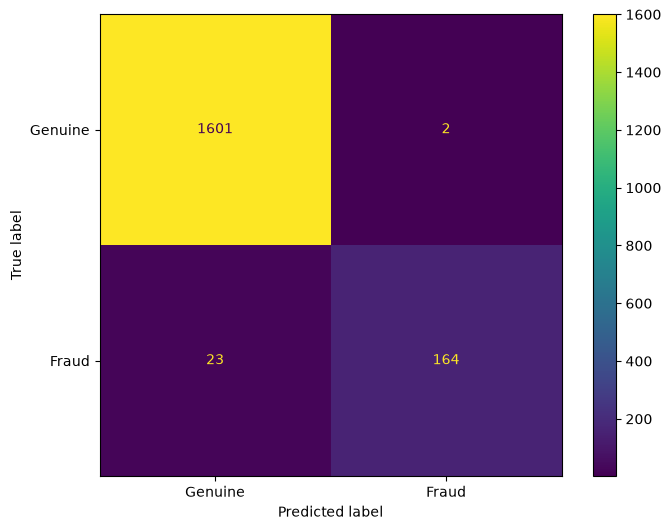

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lgbm), display_labels=['Genuine', 'Fraud'])
fig, ax = plt.subplots(figsize=(8, 6))
cm.plot(ax=ax)
plt.show()

## Model Selection: Comparing All Four Candidates Against the Project's Objective

| Model | Precision | Recall | F1 | ROC AUC | False Positives | False Negatives |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.80 | 0.88 | 0.84 | 0.9515 | 42 | 22 |
| Random Forest | 0.99 | 0.88 | 0.93 | 0.9442 | 2 | 23 |
| XGBoost | 0.98 | 0.88 | 0.92 | 0.9460 | 4 | 23 |
| LightGBM | 0.99 | 0.88 | 0.93 | 0.9442 | 2 | 23 |

(1,790 held-out test transactions, split at the customer level via `GroupShuffleSplit`)

The project's objective is to flag fraud without disrupting genuine customers at scale, since both error types carry a real cost, not just one. A missed fraud (false negative) is money that leaves Finlora's system undetected, plus harm to the affected customer, while a false alert (false positive) blocks or delays a genuine customer's transaction, creating friction and support overhead, and at 42 false positives, as Logistic Regression produces on this test set, a real churn risk if that rate held in production.

All four models catch fraud at the same rate: recall is 0.88 across every model, meaning each currently misses the same 12% of fraud regardless of algorithm. That makes recall a tie, not a differentiator, and shifts the real decision onto false positives, where the models diverge sharply. Logistic Regression's 42 false positives is over 20x Random Forest and LightGBM's 2, and double XGBoost's 4, so it generates by far the most customer friction for no recall benefit, ruling it out despite its narrow ROC AUC lead.

Random Forest and LightGBM are statistically tied on every measured metric, confirmed by direct comparison of both models' raw prediction and probability arrays, not just matching summary numbers. Choosing between them came down to a criterion the metrics can't show: LightGBM's leaf-wise tree growth makes it faster to train and lighter at inference than Random Forest's per-tree bagging, which matters for a fraud system meant to score transactions in real time as Finlora's volume grows. XGBoost, while close behind, offered no accuracy advantage to justify its extra false positives over LightGBM/Random Forest.

**Selected model: LightGBM.** It matches the best-performing model on every accuracy metric while being better suited to production-scale, real-time scoring, which is what the project's objective actually calls for, not just the highest single number on a leaderboard.

## SHAP Explainability - LightGBM (Selected Model)

In [25]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Get the preprocessor from pipeline and transform raw X_test
X_test_processed_lgbm = pipeline_lgbm.named_steps['preprocessor'].transform(X_test)

# LightGBM's sklearn wrapper works directly with TreeExplainer, no booster extraction needed
lgbm_classifier = pipeline_lgbm.named_steps['classifier']
explainer_lgbm = shap.TreeExplainer(lgbm_classifier)
shap_values_lgbm = explainer_lgbm.shap_values(X_test_processed_lgbm)

# TreeExplainer can return a list [class_0_shap, class_1_shap] for binary classification
# depending on version — normalize to the fraud-class (index 1) array either way
shap_values_lgbm_fraud = shap_values_lgbm[1] if isinstance(shap_values_lgbm, list) else shap_values_lgbm

c:\Users\hp\Downloads\Fraudulent_Transaction_Detection_for_Finlora\finlora_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\hp\Downloads\Fraudulent_Transaction_Detection_for_Finlora\finlora_env\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


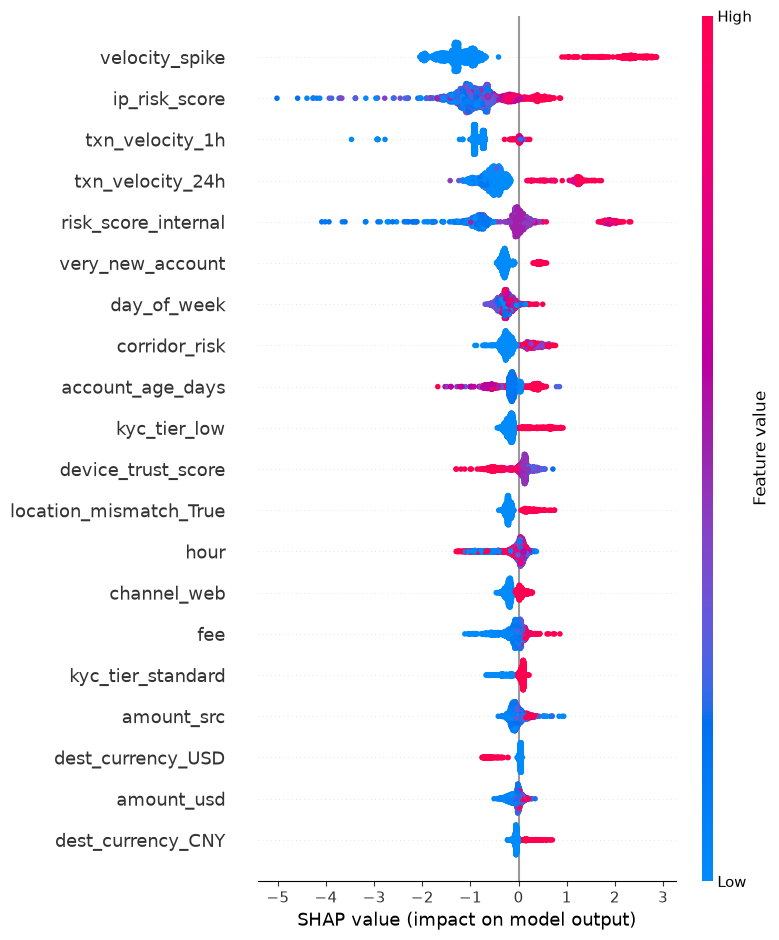

In [26]:
feature_names_lgbm = pipeline_lgbm.named_steps['preprocessor'].get_feature_names_out()
clean_names_lgbm = [name.replace("num__", "").replace("cat__", "") for name in feature_names_lgbm]

X_test_processed_lgbm_df = pd.DataFrame(
    X_test_processed_lgbm,
    columns=clean_names_lgbm
)

# Beeswarm plot
shap.summary_plot(shap_values_lgbm_fraud, X_test_processed_lgbm_df)
plt.show()

In [27]:
import numpy as np

mean_abs_shap_lgbm = np.abs(shap_values_lgbm_fraud).mean(axis=0)
importance_df_lgbm = pd.DataFrame({
    'feature': clean_names_lgbm,
    'mean_abs_shap': mean_abs_shap_lgbm
}).sort_values('mean_abs_shap', ascending=False)

importance_df_lgbm

,feature,mean_abs_shap
19,velocity_spike,1.377896
3,ip_risk_score,0.873393
8,txn_velocity_1h,0.745196
9,txn_velocity_24h,0.598120
7,risk_score_internal,0.552197
18,very_new_account,0.302450
12,day_of_week,0.273408
10,corridor_risk,0.271700
4,account_age_days,0.258651
39,kyc_tier_low,0.226148


In [28]:
print(X_train['chargeback_history_count'].value_counts())
print(X_test['chargeback_history_count'].value_counts())

chargeback_history_count
0    9004
1     259
2      87
Name: count, dtype: int64
chargeback_history_count
0    1695
1      71
2      24
Name: count, dtype: int64


In [29]:
importance_df_lgbm[importance_df_lgbm['feature'] == 'chargeback_history_count']

,feature,mean_abs_shap
6,chargeback_history_count,0.0


### chargeback_history_count - strongest EDA signal, unused by either candidate model

`chargeback_history_count` was the single strongest individual predictor found in EDA (99.1% fraud rate at 2 chargebacks, 93.0% at 1, vs. a 5.4% baseline). Despite that, it has a mean |SHAP value| of exactly 0.000000 in both the XGBoost and LightGBM models, a finding that holds across two structurally different tree algorithms, not a quirk of one.

This isn't a data or pipeline issue: `chargeback_history_count` genuinely varies in the test set (95 of 1,790 rows are nonzero). The most likely explanation is redundancy: `velocity_spike` alone carries more than double the SHAP importance of any other feature in both models (1.32 for XGBoost, 1.38 for LightGBM), and the earlier leakage check found only 42% of fraud rows carry any chargeback history at all, so it was never going to explain most fraud alone. The rows chargeback history would help identify appear to be the same rows the models' dominant features (`velocity_spike`, `ip_risk_score`, `txn_velocity_1h`/`24h`) already separate correctly on their own.

Worth flagging for future work: a feature can be a strong signal in isolation and still be functionally unused once stronger, overlapping features are present, and that conclusion is now confirmed independently by two different algorithms rather than one model's particular split logic.

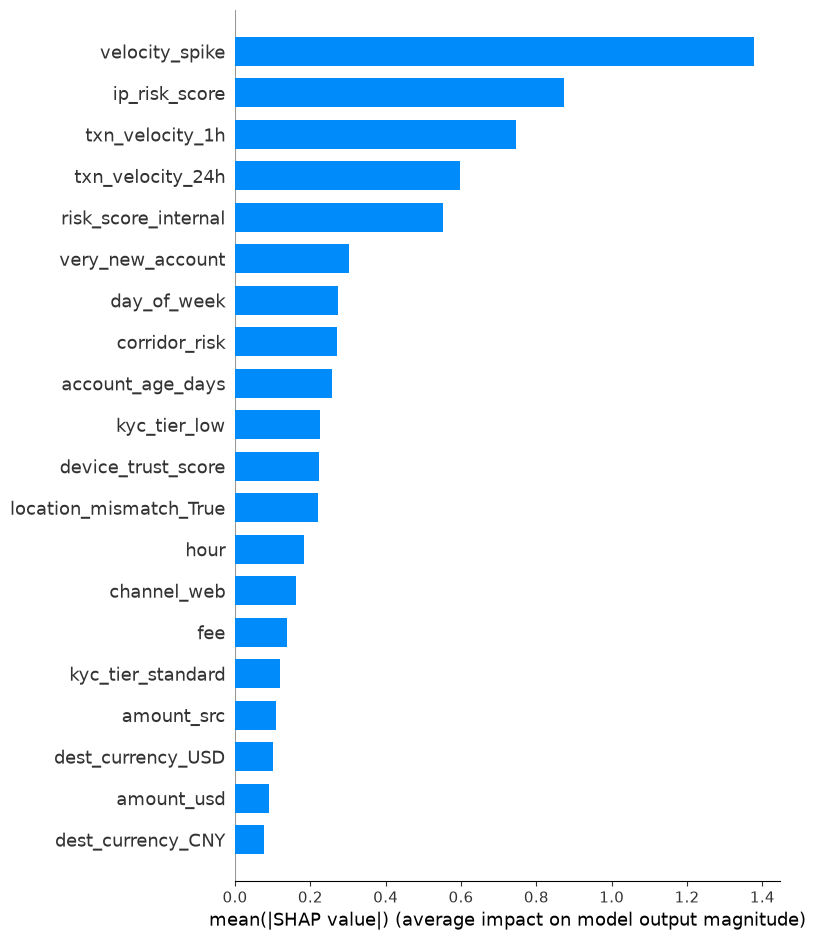

In [30]:
# Summary bar plot
shap.summary_plot(shap_values_lgbm_fraud, X_test_processed_lgbm_df, plot_type="bar")
plt.show()

Model Registering

In [31]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize DagsHub, using my repo
dagshub.init(
    repo_owner='uzoegwuchekwubechris',
    repo_name='Fraudulent_Transaction_Detection_for_Finlora',
    mlflow=True
)

# Set experiment
mlflow.set_experiment("Fraudulent_Transaction_Detection_for_Finlora_Company")

Accessing as uzoegwuchekwubechris

Initialized MLflow to track repo "uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora"

Repository uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora initialized!

<Experiment: artifact_location='mlflow-artifacts:/b05e7ec9ae634bb0b420583435eac868', creation_time=1788385222478, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1788385222478, lifecycle_stage='active', name='Fraudulent_Transaction_Detection_for_Finlora_Company', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [32]:
# Already executed — registered as Fraud_Detection_XGBoost_Pipeline v1 in DagsHub.
# Commented out to prevent duplicate versions on kernel restart / run all.
# with mlflow.start_run(run_name="XGBoost_SMOTE") as run:
#     mlflow.log_params(xgb_model.get_params())
#     ...

In [33]:
# Start MLflow run and register the XGBoost model
# Already executed — registered as Fraud_Detection_XGBoost_Pipeline v1 in DagsHub.
# Commented out to prevent duplicate versions on kernel restart / run all.

#   with mlflow.start_run(run_name="XGBoost_SMOTE") as run:
    # Log model hyperparameters
    # mlflow.log_params(xgb_model.get_params())

    # # Predict using the full pipeline (preprocessing + trained classifier)
    # y_pred = pipeline_xgb.predict(X_test)
    # y_pred_proba = pipeline_xgb.predict_proba(X_test)[:, 1]

    # # Log evaluation metrics — recall and auc_roc matter most here given the fraud imbalance
    # mlflow.log_metrics({
    #     'accuracy': accuracy_score(y_test, y_pred),
    #     'precision': precision_score(y_test, y_pred),
    #     'recall': recall_score(y_test, y_pred),
    #     'f1_score': f1_score(y_test, y_pred),
    #     'auc_roc': roc_auc_score(y_test, y_pred_proba)
    # })

    # # Log the entire pipeline (preprocessor + model), cloudpickle since the pipeline
    # # contains a SMOTE step and imblearn's Pipeline isn't a plain sklearn object
    # mlflow.sklearn.log_model(
    #     pipeline_xgb,
    #     "xgboost_fraud_detection_pipeline",
    #     registered_model_name="Fraud_Detection_XGBoost_Pipeline",
    #     serialization_format='cloudpickle'
    # )

In [34]:
# # Registering the LightGBM pipeline — selected over XGBoost/RF per the model comparison above
# with mlflow.start_run(run_name="LightGBM_SMOTE") as run:
#     mlflow.log_params(lgbm_model.get_params())

#     # Predict using the full pipeline (preprocessing + trained classifier)
#     y_pred = pipeline_lgbm.predict(X_test)
#     y_pred_proba = pipeline_lgbm.predict_proba(X_test)[:, 1]

#     # Log evaluation metrics — recall and auc_roc matter most here given the fraud imbalance
#     mlflow.log_metrics({
#         'accuracy': accuracy_score(y_test, y_pred),
#         'precision': precision_score(y_test, y_pred),
#         'recall': recall_score(y_test, y_pred),
#         'f1_score': f1_score(y_test, y_pred),
#         'auc_roc': roc_auc_score(y_test, y_pred_proba)
#     })

#     # Log the entire pipeline (preprocessor + model), cloudpickle since the pipeline
#     # contains a SMOTE step and imblearn's Pipeline isn't a plain sklearn object
#     mlflow.sklearn.log_model(
#         pipeline_lgbm,
#         "lightgbm_fraud_detection_pipeline",
#         registered_model_name="Fraud_Detection_LightGBM_Pipeline",
#         serialization_format='cloudpickle'
#     )

In [35]:
# Import and run the MLflow/DagsHub setup function
# Verifies that src/utility/mlflow_setup.py is correctly importable
# and initializes tracking for this session (needed before logging or loading models)
from src.utility.mlflow_setup import setup_mlflow
setup_mlflow()

Initialized MLflow to track repo "uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora"

Repository uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora initialized!

In [36]:
# Load the registered LightGBM pipeline from the MLflow Model Registry on DagsHub
from src.utility.model_loader import load_registered_model

# Pulls the "latest" version of Fraud_Detection_LightGBM_Pipeline
# (currently v1) — downloads the full pipeline: preprocessor + trained model
model = load_registered_model()

# Confirms what was loaded — should print the full sklearn/imblearn Pipeline object
print(model)

Initialized MLflow to track repo "uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora"

Repository uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora initialized!

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour',
       'day_of_week', 'is_weekend', 'late_night_hours', 'high_ip_ris...
       'velocity_spike'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc

In [37]:
# Open the MLflow tracking UI (hosted on DagsHub) directly from code
import mlflow
import webbrowser

# Requires setup_mlflow() to have already run in this session,
# since that's what sets the tracking URI via dagshub.init()
tracking_uri = mlflow.get_tracking_uri()
print(tracking_uri)

# Launches the URL in your default browser
webbrowser.open(tracking_uri)

https://dagshub.com/uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora.mlflow


True

## Verifying End-to-End Prediction Pipeline

Confirms `load_registered_model()`, `load_historical_data()`, and
`predict_transaction()` work together correctly against a real transaction
from the dataset, rather than assuming the pieces integrate cleanly just
because each function tested fine in isolation. The prediction was checked
against the transaction's true `is_fraud` label as a basic sanity check.

In [38]:
import pandas as pd
from src.utility.mlflow_setup import setup_mlflow
from src.utility.model_loader import load_registered_model
from src.inference.prediction import load_historical_data, predict_transaction

# Load the trained model and historical data, same as before
setup_mlflow()
model = load_registered_model()
load_historical_data('../Finlora_Dataset/artifacts/Cleaned_Data.csv')

# Use one real transaction from your own data as the test case —
# not a fabricated dict, so we know the field names/types are correct
df_cleaned = pd.read_csv('../Finlora_Dataset/artifacts/Cleaned_Data.csv')
sample_transaction = df_cleaned.drop(columns=['is_fraud']).iloc[0].to_dict()

prediction, probability, _ = predict_transaction(model, sample_transaction)
print(f"Prediction: {prediction}")
print(f"Fraud probability: {probability:.4f}")

Initialized MLflow to track repo "uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora"

Repository uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora initialized!

Initialized MLflow to track repo "uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora"

Repository uzoegwuchekwubechris/Fraudulent_Transaction_Detection_for_Finlora initialized!

loaded 11140
found 1315 unique customer..
Prediction: 0
Fraud probability: 0.0190


In [39]:
print(df_cleaned.iloc[0]['is_fraud'])

0


In [40]:
fraud_row = df_cleaned[df_cleaned['is_fraud'] == 1].iloc[0].to_dict()
prediction, probability, _ = predict_transaction(model, fraud_row)
print(f"Prediction: {prediction}, Fraud probability: {probability:.4f}")

Prediction: 0, Fraud probability: 0.0512


Tested against a known-fraud transaction as well. The model missed this one
(predicted genuine, 5.12% fraud probability), consistent with the model's
measured recall of ~88% on the test set (see MLflow run `LightGBM_SMOTE`),
not a sign the pipeline is broken.